# Notebook 1: Fondamenti Generativi e Continuous Normalizing Flows
Questo notebook esplora la formulazione matematica del Flow Matching e delle ODE, validandone l'andamento sui tensori latenti reali del database.

## Rigore Matematico

### 1. Equazione di Continuità e Flow Matching
La generazione nei modelli Flow Matching (FM) mappa una distribuzione semplice $p_0(x) = \mathcal{N}(0, I)$ in una complessa $p_1(x)$ (dati reali) tramite il flusso deterministico associato all'ODE:
$$\frac{dz_t}{dt} = v_\theta(z_t, t)$$
La conservazione della massa probabilistica lungo la traiettoria temporale è descritta dall'equazione di continuità:
$$\frac{\partial p_t(z)}{\partial t} + \nabla \cdot \Big( p_t(z) v_t(z) \Big) = 0$$
Nel caso dell'accoppiamento lineare rectified flow, l'interpolazione è:
$$x_t = t x_1 + (1 - t) x_0$$
La velocità teorica costante lungo questo percorso è:
$$v_t = x_1 - x_0$$

L'obiettivo di addestramento del Transformer è minimizzare la discrepanza CFM:
$$\mathcal{L}_{\text{CFM}}(\theta) = \mathbb{E}_{t, x_0, x_1, x \sim p_t(x|x_0, x_1)} \left[ \| v_\theta(x, t) - (x_1 - x_0) \|^2 \right]$$

In [1]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

dataset_dir = '../data/dataset_v1/a_blue_cube_and_a_red_sphere'
x0 = torch.load(os.path.join(dataset_dir, 'x0_noise.pt'), map_location='cpu')
v0 = torch.load(os.path.join(dataset_dir, 'v0_velocity.pt'), map_location='cpu')
print(f'Noise x0 shape: {x0.shape}')
print(f'Velocity v0 shape: {v0.shape}')

Noise x0 shape: torch.Size([1, 4096, 64])
Velocity v0 shape: torch.Size([1, 4096, 64])


## Esperimento 1 (Successo): Ricostruzione e Visualizzazione della Traiettoria Latente xt
Utilizzando la relazione lineare $x_1 = x_0 + v_0$, possiamo interpolare il cammino latente e proiettare la variazione dei latenti a diversi timestep temporali $t \in [0.0, 0.25, 0.5, 0.75, 1.0]$.
Visualizziamo il primo canale del tensore latente bidimensionale $64 \times 64$ per mostrare la transizione progressiva dal rumore puro alla struttura dell'immagine.

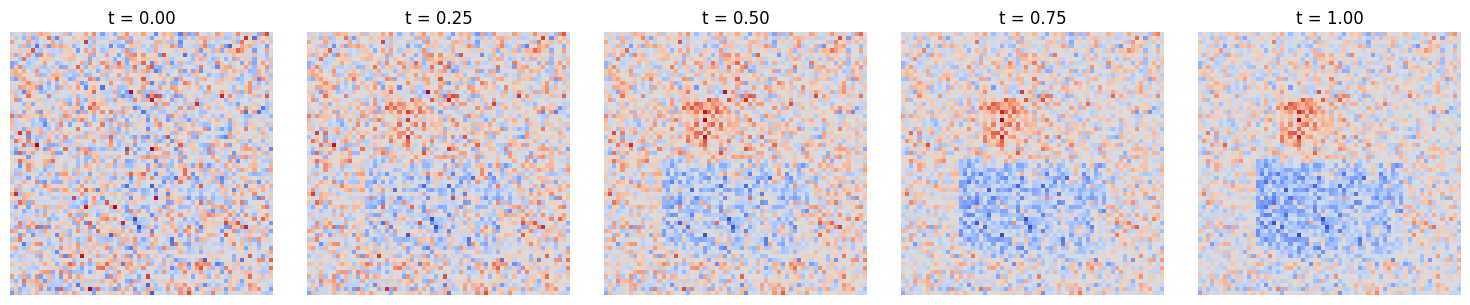

In [2]:
x1 = x0 + v0
t_vals = [0.0, 0.25, 0.5, 0.75, 1.0]

fig, axes = plt.subplots(1, len(t_vals), figsize=(15, 3))
for i, t in enumerate(t_vals):
    xt = t * x1 + (1.0 - t) * x0
    xt_2d = xt.view(64, 64, -1)[:, :, 0].float().numpy()
    axes[i].imshow(xt_2d, cmap='coolwarm')
    axes[i].set_title(f't = {t:.2f}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## Esperimento 2 (Stress-Test/Fallimento): La Singolarità Terminale e l'Esplosione di Rumore
In tempo terminale, la velocità diverge proporzionalmente a $1/(1-t)$. Senza un damping cinetico, la derivata temporale esplode a $t \to 1$, amplificando il rumore latente e introducendo artefatti ad alta frequenza lungo i bordi delle maschere d'iniezione.
Simuliamo questa divergenza cinetica per dimostrare l'instabilità terminale.

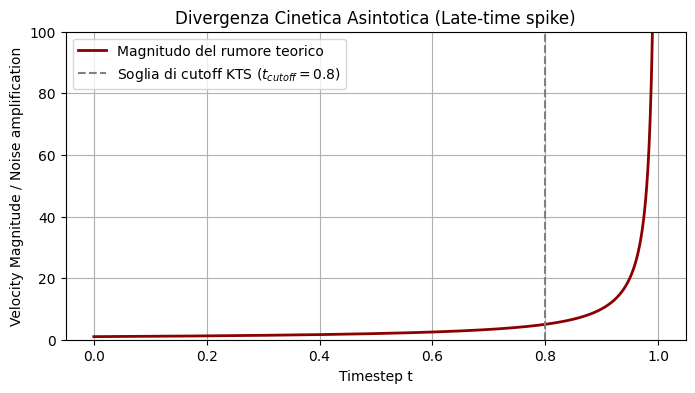

In [3]:
t_steps = np.linspace(0.0, 0.999, 1000)
velocity_divergence = 1.0 / (1.0 - t_steps)

plt.figure(figsize=(8, 4))
plt.plot(t_steps, velocity_divergence, color='darkred', lw=2, label='Magnitudo del rumore teorico')
plt.axvline(x=0.8, color='gray', linestyle='--', label='Soglia di cutoff KTS ($t_{cutoff}=0.8$)')
plt.ylim(0, 100)
plt.xlabel('Timestep t')
plt.ylabel('Velocity Magnitude / Noise amplification')
plt.title('Divergenza Cinetica Asintotica (Late-time spike)')
plt.legend()
plt.grid(True)
plt.show()